# 招聘岗位数据清洗与分析项目

## 1. 项目背景
本项目基于 Kaggle 招聘岗位数据，对岗位信息进行清洗、分类和分析，重点关注岗位分布、薪资水平、地域分布和技能需求。

## 2. 数据读取

In [73]:
import pandas as pd 
df = pd.read_csv("../data/raw/job_raw.csv")
df.head()


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


## 3. 数据概览

In [74]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   str    
 2   Salary Estimate    2253 non-null   str    
 3   Job Description    2253 non-null   str    
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   str    
 6   Location           2253 non-null   str    
 7   Headquarters       2253 non-null   str    
 8   Size               2253 non-null   str    
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   str    
 11  Industry           2253 non-null   str    
 12  Sector             2253 non-null   str    
 13  Revenue            2253 non-null   str    
 14  Competitors        2253 non-null   str    
 15  Easy Apply         2253 non-null   str    
dtypes: float64(1), int64(2), str(13)
me

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

可分析方向：
岗位名称分析：Job Title
薪资分析：Salary Estimate
公司评分分析：Rating
地点分析：Location
公司类型分析：Type of ownership
行业 / 赛道分析：Industry、Sector
公司规模分析：Size
是否一键投递：Easy Apply
岗位描述关键词分析：Job Description

## 4. 数据清洗

### 4.1 删除无用列

In [75]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True



### 4.2 重命名列

In [76]:
df = df.rename(columns={
    "Job Title":"job_title",
    "Salary Estimate": "salary_estimate",
    "Job Description": "job_description",
    "Rating": "rating",
    "Company Name": "company_name",
    "Location": "location",
    "Headquarters": "headquarters",
    "Size": "size",
    "Founded": "founded",
    "Type of ownership": "ownership",
    "Industry": "industry",
    "Sector": "sector",
    "Revenue": "revenue",
    "Competitors": "competitors",
    "Easy Apply": "easy_apply"

})
df.columns

Index(['job_title', 'salary_estimate', 'job_description', 'rating',
       'company_name', 'location', 'headquarters', 'size', 'founded',
       'ownership', 'industry', 'sector', 'revenue', 'competitors',
       'easy_apply'],
      dtype='str')


### 4.3 处理缺失值

In [77]:
df[df["company_name"].isnull()]
df = df.dropna(subset=["company_name"])
df.isnull().sum()

job_title          0
salary_estimate    0
job_description    0
rating             0
company_name       0
location           0
headquarters       0
size               0
founded            0
ownership          0
industry           0
sector             0
revenue            0
competitors        0
easy_apply         0
dtype: int64

### 4.4 薪资字段清洗

In [78]:
df["salary_estimate"].head(10)
df["salary_estimate"].sample(10)
#随机看10个薪资，看看字段有没有不一样

1920    $99K-$178K (Glassdoor est.)
2174     $57K-$67K (Glassdoor est.)
87       $51K-$88K (Glassdoor est.)
793      $67K-$92K (Glassdoor est.)
1167    $64K-$113K (Glassdoor est.)
1993    $82K-$116K (Glassdoor est.)
1549    $69K-$127K (Glassdoor est.)
242      $45K-$88K (Glassdoor est.)
1213     $37K-$68K (Glassdoor est.)
529     $55K-$103K (Glassdoor est.)
Name: salary_estimate, dtype: str

In [79]:
#虽然看不出薪资字段有没有不统一，还是要写清洗函数

import re

def clean_salary(s):
    s = s.replace("(Glassdoor est.)","")
    s = s.replace("$","")
    s = s.replace("K","")
    s = s.strip()

    match = re.findall(r"\d+",s)
    if len(match) >= 2:
        low = int(match[0])
        high = int(match[1])
        avg = (low+high) / 2
        return low,high,avg
    else:
        return None,None,None
    
df[["salary_min","salary_max","salary_avg"]] = df["salary_estimate"].apply(
    lambda x: pd.Series(clean_salary(x)))
df[["salary_estimate", "salary_min", "salary_max", "salary_avg"]].head()

,salary_estimate,salary_min,salary_max,salary_avg
0,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
1,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
2,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
3,$37K-$66K (Glassdoor est.),37.0,66.0,51.5
4,$37K-$66K (Glassdoor est.),37.0,66.0,51.5


In [80]:
df[["salary_min","salary_max","salary_avg"]].isnull().sum()

salary_min    1
salary_max    1
salary_avg    1
dtype: int64

(0,18)代表  0行，18列

In [81]:
df[df["salary_avg"].isnull()][["salary_estimate"]].drop_duplicates()
df[df["salary_estimate"] == "-1"].shape

(1, 18)

In [82]:
df = df.dropna(subset=["salary_avg"])
df[["salary_min","salary_max","salary_avg"]].isnull().sum()

salary_min    0
salary_max    0
salary_avg    0
dtype: int64

### 4.5 地点字段拆分

In [83]:
df['location'].head(10)
df["location"].sample(20)
df["location"].str.count(",").value_counts()

location
1    2243
2       8
Name: count, dtype: int64

In [84]:
location_split = df["location"].str.split(",",n=1,expand=True)
df["city"] = location_split[0].str.strip()
df["state"] = location_split[1].str.strip()
df

,job_title,salary_estimate,job_description,rating,company_name,location,headquarters,size,founded,ownership,industry,sector,revenue,competitors,easy_apply,salary_min,salary_max,salary_avg,city,state
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True,37.0,66.0,51.5,New York,NY
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37.0,66.0,51.5,New York,NY
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37.0,66.0,51.5,New York,NY
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37.0,66.0,51.5,New York,NY
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37.0,66.0,51.5,New York,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1,78.0,104.0,91.0,Denver,CO
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78.0,104.0,91.0,Centennial,CO
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1,78.0,104.0,91.0,Denver,CO
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1,78.0,104.0,91.0,Centennial,CO


In [85]:
df[["city","state"]].isnull().sum()

city     0
state    0
dtype: int64

In [86]:
df[df["state"].isnull()][["location"]].drop_duplicates().head(20)
#  筛完行，                再选列”

,location


### 4.6 公司名称清洗

In [87]:
df["company_name"].head(10)
df["company_name"].sample(20,random_state=42)

1666    Texas Health & Human Services Commission\n2.8
1809                               Diversant LLC\n3.8
582                                     Tillster\n3.3
247                                      APR Staffing
1820                          Data Bridge Consultants
874                                Kbyte Systems LLC.
1886                     PruTech Solutions, Inc.\n3.8
430                                  Akraya Inc.\n4.6
1805                                  Artech LLC\n3.9
438                                    Ascential\n3.4
303                              Mitchell Martin\n4.1
741                                          BMO\n3.2
2002            Staffigo Technical Services, LLC\n5.0
1053                                      Kforce\n4.1
1268                             Tandem Diabetes\n3.8
1594                                  Boston Services
879                      Lorven Technologies Inc\n4.0
2041                                        BOLD\n3.6
1034                        

In [88]:
df["company_name_clean"] = df["company_name"].str.split("\n").str[0].str.strip()
df["company_name_clean"].head(10)
df["company_name_clean"].nunique()

1501

In [89]:
df["company_name_clean"].value_counts().head(20)
#最常见的公司

company_name_clean
Staffigo Technical Services, LLC    58
Diverse Lynx                        22
Kforce                              19
Lorven Technologies Inc             19
Robert Half                         14
Mondo                               14
Avacend, Inc.                       13
eTeam Inc.                          10
Apex Systems                        10
Apple                               10
Reliable Software Resources          9
APN Software Services Inc.           9
Randstad                             8
TechUSA                              8
Citi                                 7
Capgemini                            7
The Bank of New York Mellon          7
MUFG                                 7
Collabera                            7
Perficient                           6
Name: count, dtype: int64

## 5. 岗位分类

In [90]:
df["job_title"].value_counts().sample(30)

job_title
Data/Report Analyst                                                                                                   1
Data Validation Analyst                                                                                               1
Sr. Principal Metrics Analyst- Data Scientist                                                                         1
Application Vulnerability Governance Lead Data Analyst                                                                1
Job Opportunity with Cognizant for Data Analyst at SFO ,CA (NO OPT & NO CPT)                                          1
Data Analyst, Value Based Payment (VBP)                                                                               1
Program Analyst - AIS/Maintenance Data System Coordinator                                                             1
Data Technician/Analyst/Specialist                                                                                    2
Product Analyst - Data        

In [91]:
def classify_job(title):
    title = title.lower()

     # 先匹配更具体、更容易混淆的岗位
    if "business intelligence" in title or "bi analyst" in title or "bi developer" in title:
        return "BI Analyst"
    
    elif "business analyst" in title:
        return "Business Analyst"
    
    elif "data science" in title or "data scientist" in title or "machine learning" in title:
        return "Data Scientist"
    
    elif "data engineer" in title or "data systems" in title or "big data" in title:
        return "Data Engineer"
    
    elif "data governance" in title or "data integrity" in title or "data policy" in title or "data and user acceptance" in title:
        return "Data Governance Analyst"
    
    elif "report analyst" in title or "reporting analyst" in title:
        return "Report Analyst"
    
    elif "quality analyst" in title:
        return "Quality Analyst"
    
    elif "warehouse analyst" in title:
        return "Warehouse Analyst"
    
    elif "data analyst" in title:
        return "Data Analyst"
    
    elif "data collection" in title or "data visualization" in title:
        return "Data Analyst"
    
    elif "operations analyst" in title or "data operations" in title:
        return "Data Analyst"
    
    else:
        return "Other Analyst"
    
df["job_category"] = df["job_title"].apply(classify_job)


## 6. 探索性分析

### 6.1 岗位类别分布

#### 6.1.1比较不同岗位类别的技能需求差异

          Data Analyst  Data Scientist  Data Engineer  BI Analyst  \
aws                208               4             12           2   
excel             1008              20             14          10   
hadoop              89              10             20           0   
power bi           192               3              3           5   
python             479              21             21          10   
spark               55               7             17           0   
sql               1084              22             26          15   
tableau            469              15             12           6   

          Business Analyst  
aws                      9  
excel                   47  
hadoop                   3  
power bi                 9  
python                  15  
spark                    2  
sql                     38  
tableau                 17  


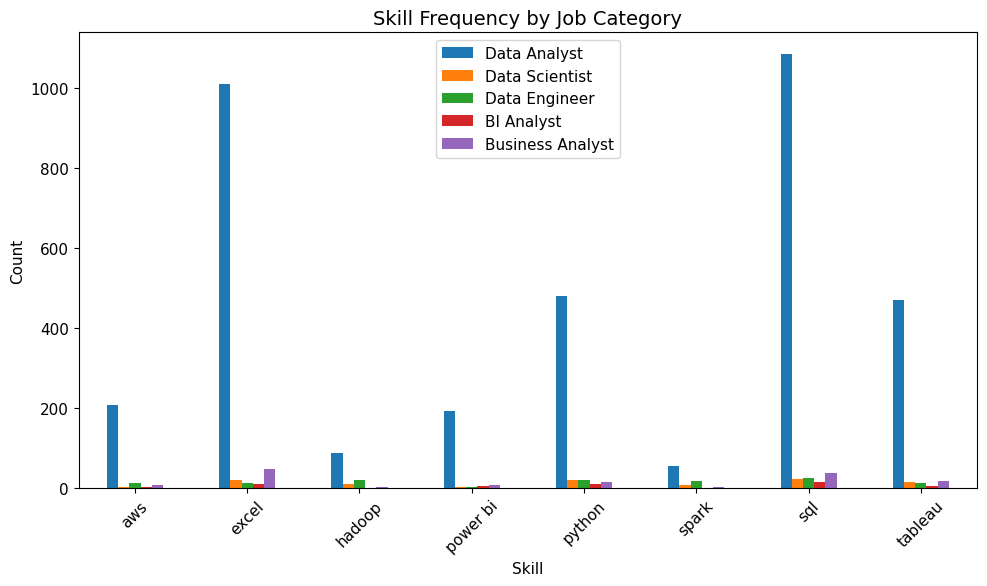


Data Analyst Top 3 Skills:
sql       1084
excel     1008
python     479
Name: Data Analyst, dtype: int64

Data Scientist Top 3 Skills:
sql       22
python    21
excel     20
Name: Data Scientist, dtype: int64

Data Engineer Top 3 Skills:
sql       26
python    21
hadoop    20
Name: Data Engineer, dtype: int64

BI Analyst Top 3 Skills:
sql       15
excel     10
python    10
Name: BI Analyst, dtype: int64

Business Analyst Top 3 Skills:
excel      47
sql        38
tableau    17
Name: Business Analyst, dtype: int64


In [92]:


skills = [
    "sql", "excel", "python", "tableau",
    "aws", "power bi", "powerbi", "hadoop", "spark"
]

target_categories = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "BI Analyst",
    "Business Analyst"
]

def count_skills_by_category(df, category, skills):
    sub_df = df[df["job_category"] == category].copy()
    desc_series = sub_df["job_description"].fillna("").str.lower()
    
    skill_count = {}
    for skill in skills:
        if skill == "power bi":
            count = desc_series.str.contains("power bi|powerbi", regex=True).sum()
        elif skill == "powerbi":
            continue
        else:
            count = desc_series.str.contains(skill, regex=False).sum()
        skill_count[skill] = count
    
    return pd.Series(skill_count).sort_values(ascending=False)

category_skill_summary = {}

for category in target_categories:
    category_skill_summary[category] = count_skills_by_category(df, category, skills)

category_skill_df = pd.DataFrame(category_skill_summary).fillna(0).astype(int)

print(category_skill_df)

category_skill_df.plot(kind="bar", figsize=(10, 6))
plt.title("Skill Frequency by Job Category")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/skill_frequency_by_job_category.png", dpi=300, bbox_inches="tight")
plt.show()

for category in target_categories:
    print(f"\n{category} Top 3 Skills:")
    print(category_skill_df[category].sort_values(ascending=False).head(3))

#### 6.1.2 不同岗位类别的技能出现率分析

          Data Analyst  Data Scientist  Data Engineer  BI Analyst  \
aws           0.125984        0.114286       0.292683    0.105263   
excel         0.610539        0.571429       0.341463    0.526316   
hadoop        0.053907        0.285714       0.487805    0.000000   
power bi      0.116293        0.085714       0.073171    0.263158   
python        0.290127        0.600000       0.512195    0.526316   
spark         0.033313        0.200000       0.414634    0.000000   
sql           0.656572        0.628571       0.634146    0.789474   
tableau       0.284070        0.428571       0.292683    0.315789   

          Business Analyst  
aws               0.121622  
excel             0.635135  
hadoop            0.040541  
power bi          0.121622  
python            0.202703  
spark             0.027027  
sql               0.513514  
tableau           0.229730  


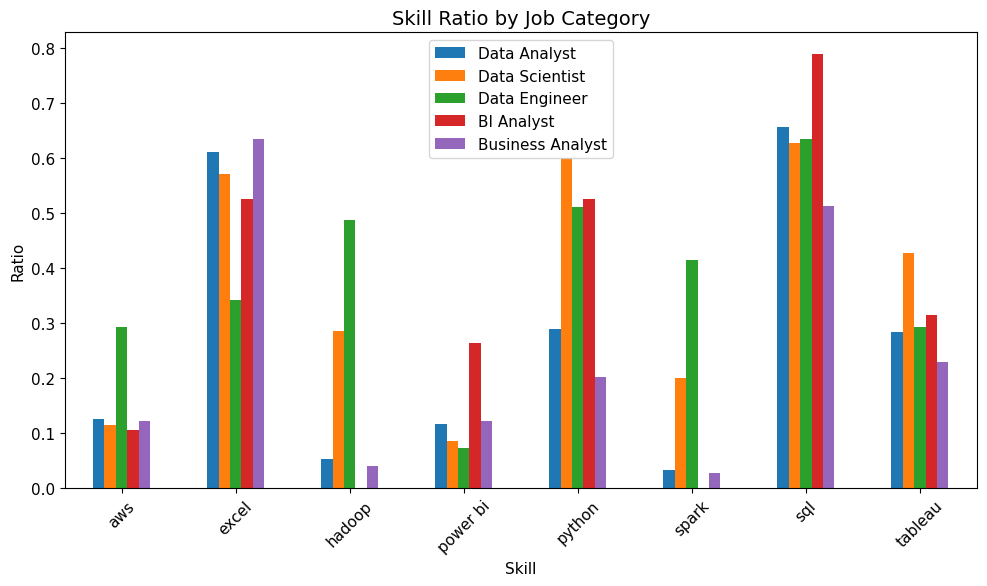

In [102]:
skills = ["sql", "excel", "python", "tableau", "aws", "power bi", "hadoop", "spark"]

target_categories = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer",
    "BI Analyst",
    "Business Analyst"
]

def skill_ratio_by_category(df, category, skills):
    sub_df = df[df["job_category"] == category].copy()
    desc_series = sub_df["job_description"].fillna("").str.lower()
    total_jobs = len(sub_df)

    skill_ratio = {}
    for skill in skills:
        if skill == "power bi":
            count = desc_series.str.contains("power bi|powerbi", regex=True).sum()
        else:
            count = desc_series.str.contains(skill, regex=False).sum()

        ratio = count / total_jobs if total_jobs > 0 else 0
        skill_ratio[skill] = ratio

    return pd.Series(skill_ratio).sort_values(ascending=False)

category_skill_ratio = {}

for category in target_categories:
    category_skill_ratio[category] = skill_ratio_by_category(df, category, skills)

category_skill_ratio_df = pd.DataFrame(category_skill_ratio)
print(category_skill_ratio_df)

import matplotlib.pyplot as plt

category_skill_ratio_df.plot(kind="bar", figsize=(10, 6))
plt.title("Skill Ratio by Job Category")
plt.xlabel("Skill")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/skill_ratio_by_job_category.png", dpi=300, bbox_inches="tight")
plt.show()

### 不同岗位类别的技能出现率分析
为消除不同岗位类别样本量差异带来的影响，进一步采用技能出现率对不同岗位类别的技能需求进行比较。

分析结果显示：

- SQL 在各类数据岗位中均具有较高出现率，是最核心的通用技能，其中 BI Analyst 对 SQL 的依赖最强。
- Excel 在 Data Analyst、BI Analyst 和 Business Analyst 中出现率较高，说明分析类与业务类岗位仍然高度依赖表格分析工具。
- Python 在 Data Scientist 和 Data Engineer 中出现率更高，说明技术型岗位更强调编程与数据处理能力。
- Hadoop、Spark、AWS 等技能在 Data Engineer 中出现率明显更高，反映出该岗位更偏向大数据处理和工程化能力。
- Business Analyst 更侧重 SQL 和 Excel，而对 Hadoop、Spark 等工程技术要求较低，体现出其更偏业务分析和决策支持的岗位属性。

总体来看，不同数据类岗位虽然都属于数据方向，但在技能要求上存在明显分工：分析类岗位更偏 SQL 与 Excel，技术类岗位更偏 Python 与大数据相关技术。

In [93]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
#统一图格式

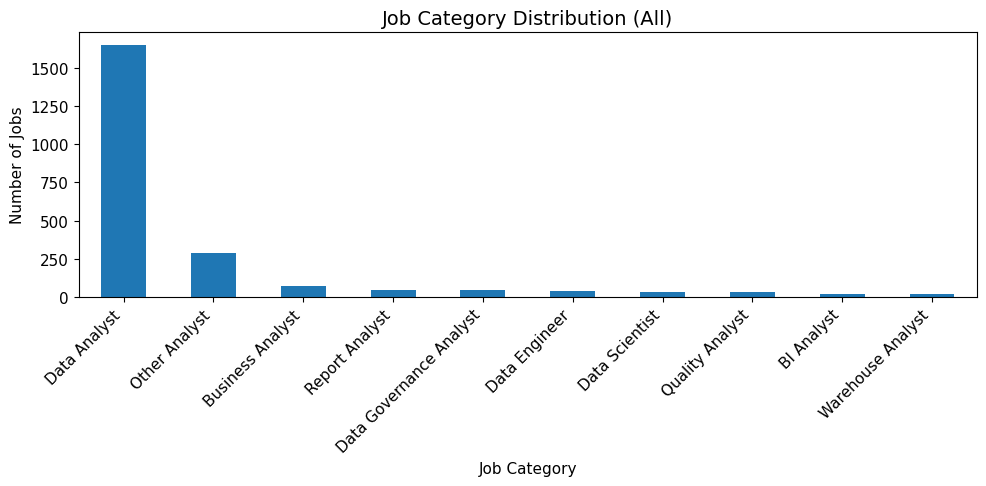

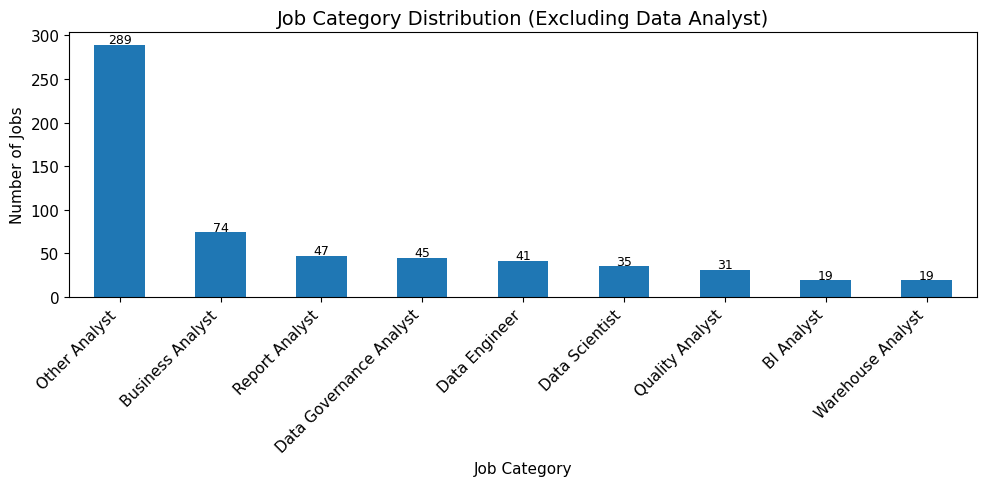

In [103]:
import matplotlib.pyplot as plt
job_counts = df["job_category"].value_counts()

# 全体分布
ax = job_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Job Category Distribution (All)")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/job_category_distribution_all.png", dpi=300, bbox_inches="tight")
plt.show()

# 去掉 Data Analyst
job_counts_no_da = job_counts.drop("Data Analyst")

ax = job_counts_no_da.plot(kind="bar", figsize=(10, 5))
plt.title("Job Category Distribution (Excluding Data Analyst)")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(job_counts_no_da.values):
    ax.text(i, v + 2, str(v), ha="center", fontsize=9)



plt.tight_layout()
plt.savefig("../figures/job_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
#岗位类别数量柱状图

In [95]:
df[df["job_category"] == "Other Analyst"][["job_title"]].value_counts().head(30)

job_title                                                         
Data Management Analyst                                               8
Data Security Analyst                                                 6
Data Base Programmer/Analyst                                          4
Analyst, Financial Master Data                                        3
Division Data and Financial Analyst                                   3
Data Analytics Analyst or Associate, Cowen Sustainable Investments    2
Senior Analyst, Data Instrumentation & Quality (Disney+)              2
2021 Summer Analyst Program- Data & Analytics Solutions               2
Senior Analyst, Data Analytics                                        2
Tactical Data Link (TDL) Analyst                                      2
Data and Policy Analyst - Statistical Programmer                      2
Data and Policy Analyst - Writer/Coordinator                          2
Data Intelligence Analyst                                            

### 6.2 各岗位平均薪资

In [96]:
df.groupby("job_category")["salary_avg"].mean().sort_values(ascending=False)
#各岗位类别平均薪资

job_category
Warehouse Analyst          73.500000
Report Analyst             72.882979
Data Analyst               72.633253
Other Analyst              72.482699
BI Analyst                 71.763158
Data Engineer              70.878049
Quality Analyst            68.080645
Data Governance Analyst    68.033333
Business Analyst           66.432432
Data Scientist             65.728571
Name: salary_avg, dtype: float64

Data Analyst 数量远高于其他类别
Other 也很多，说明岗位标题分类规则还可以继续优化
Data Scientist / Data Engineer / BI Analyst 样本相对少

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
series_or_df.plot(kind="bar")

plt.title("图表标题", fontsize=14)
plt.xlabel("X轴标题", fontsize=11)
plt.ylabel("Y轴标题", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
美化柱状图模板
figsize=(10, 5)：控制图大小

title()：图标题

xlabel()/ylabel()：坐标轴名字

xticks(rotation=45)：横轴文字倾斜，防止重叠

tight_layout()：自动调整边距，防止字被切掉

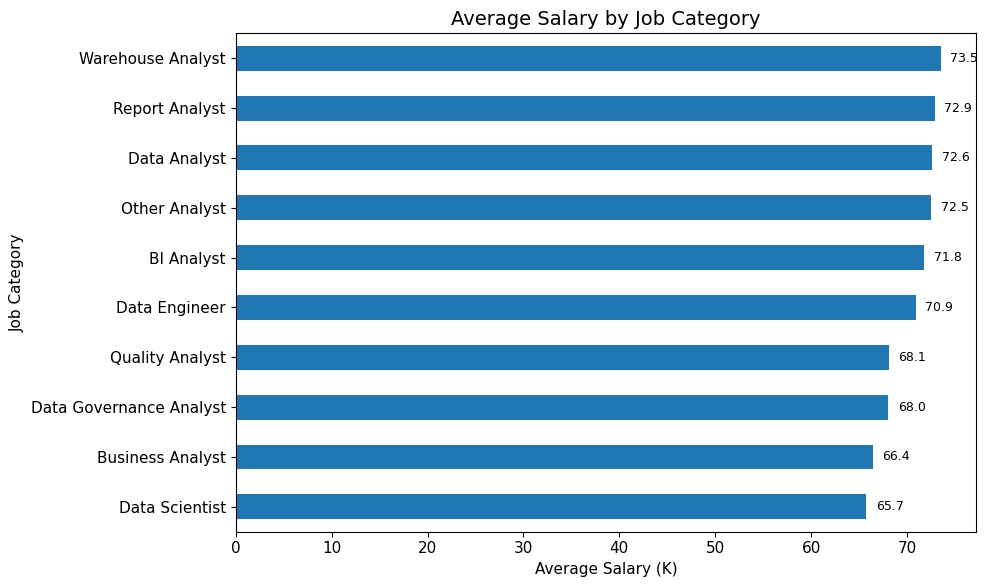

In [ ]:
salary_by_job = df.groupby("job_category")["salary_avg"].mean().sort_values()

ax = salary_by_job.plot(kind="barh", figsize=(10, 6))

plt.title("Average Salary by Job Category", fontsize=14)
plt.xlabel("Average Salary (K)", fontsize=11)
plt.ylabel("Job Category", fontsize=11)

for i, v in enumerate(salary_by_job.values):
    ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/job_category_average_salary.png", dpi=300, bbox_inches="tight")
plt.show()

#### 6.2.1 高薪岗位画像

高薪门槛: 80.5
高薪岗位数量: 591
高薪岗位占比: 0.26254997778764994

高薪岗位类别分布:
job_category
Data Analyst               439
Other Analyst               83
Business Analyst            14
Report Analyst              13
Data Engineer               10
Data Governance Analyst      9
Warehouse Analyst            7
Quality Analyst              6
Data Scientist               6
BI Analyst                   4
Name: count, dtype: int64


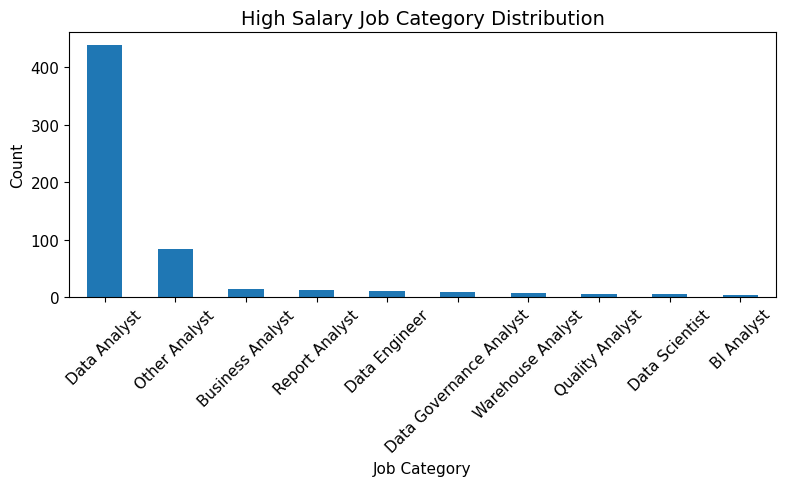


高薪岗位州分布 Top10:
state
CA    331
NY     94
TX     46
NJ     31
IL     30
PA     26
VA     18
CO     15
Name: count, dtype: int64


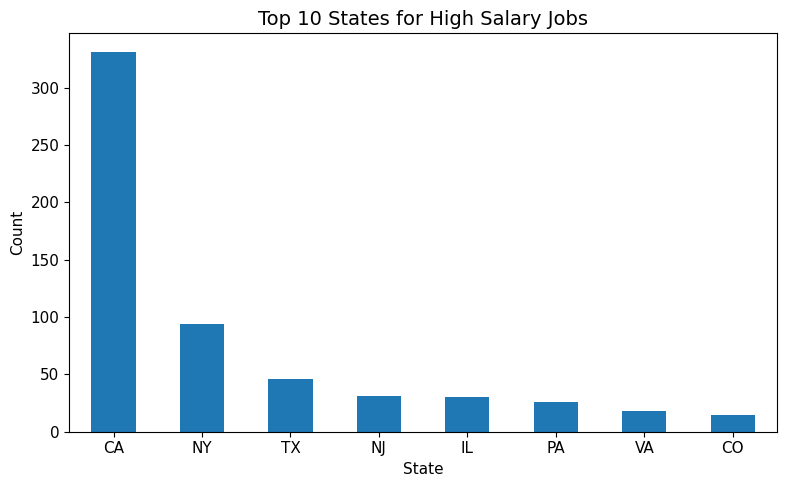


高薪岗位技能频次:
excel       354
sql         349
python      193
tableau     174
aws          72
power bi     51
hadoop       45
spark        26
dtype: int64


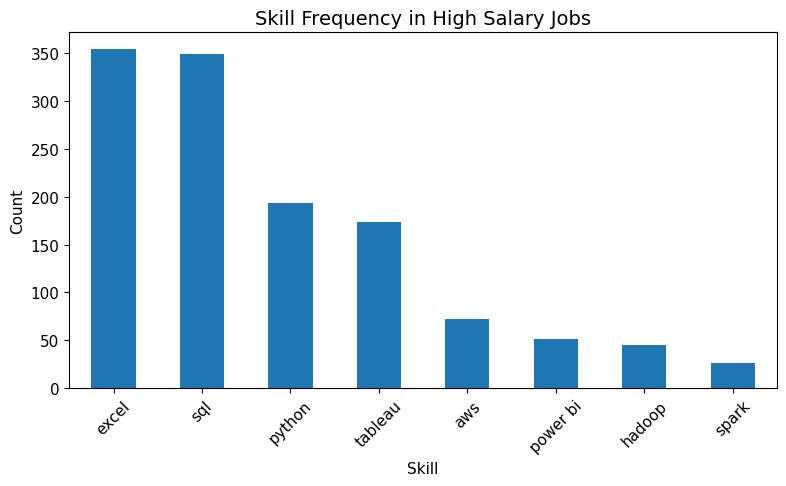


高薪岗位技能出现率:
excel       0.598985
sql         0.590525
python      0.326565
tableau     0.294416
aws         0.121827
power bi    0.086294
hadoop      0.076142
spark       0.043993
dtype: float64


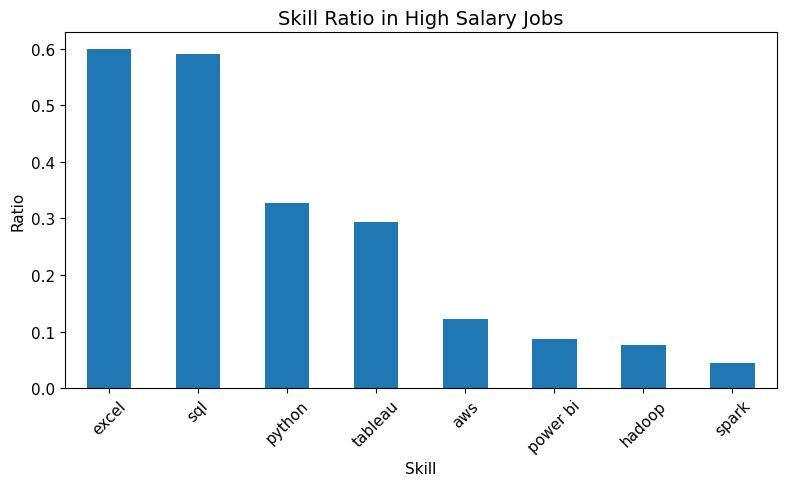

In [104]:


# 1. 定义高薪岗位
high_salary_threshold = df["salary_avg"].quantile(0.75)
high_salary_df = df[df["salary_avg"] >= high_salary_threshold].copy()

print("高薪门槛:", high_salary_threshold)
print("高薪岗位数量:", high_salary_df.shape[0])
print("高薪岗位占比:", high_salary_df.shape[0] / df.shape[0])

# 2. 高薪岗位类别分布
high_salary_category = high_salary_df["job_category"].value_counts()
print("\n高薪岗位类别分布:")
print(high_salary_category)

plt.figure(figsize=(8, 5))
high_salary_category.plot(kind="bar")
plt.title("High Salary Job Category Distribution")
plt.xlabel("Job Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/high_salary_job_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. 高薪岗位州分布
high_salary_state = high_salary_df["state"].value_counts().head(10)
print("\n高薪岗位州分布 Top10:")
print(high_salary_state)

plt.figure(figsize=(8, 5))
high_salary_state.plot(kind="bar")
plt.title("Top 10 States for High Salary Jobs")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/high_salary_top10_states.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. 高薪岗位技能频次
skills = ["sql", "excel", "python", "tableau", "aws", "power bi", "hadoop", "spark"]

desc_series = high_salary_df["job_description"].fillna("").str.lower()
high_salary_skill_count = {}

for skill in skills:
    if skill == "power bi":
        count = desc_series.str.contains("power bi|powerbi", regex=True).sum()
    else:
        count = desc_series.str.contains(skill, regex=False).sum()
    high_salary_skill_count[skill] = count

high_salary_skill_series = pd.Series(high_salary_skill_count).sort_values(ascending=False)
print("\n高薪岗位技能频次:")
print(high_salary_skill_series)

plt.figure(figsize=(8, 5))
high_salary_skill_series.plot(kind="bar")
plt.title("Skill Frequency in High Salary Jobs")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/high_salary_skill_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. 高薪岗位技能出现率
high_salary_skill_ratio = (high_salary_skill_series / len(high_salary_df)).sort_values(ascending=False)
print("\n高薪岗位技能出现率:")
print(high_salary_skill_ratio)

plt.figure(figsize=(8, 5))
high_salary_skill_ratio.plot(kind="bar")
plt.title("Skill Ratio in High Salary Jobs")
plt.xlabel("Skill")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/high_salary_skill_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

### 高薪岗位画像分析
以岗位平均薪资 `salary_avg` 的前 25% 作为高薪岗位标准，得到高薪门槛为 80.5，高薪岗位共 591 个，占总体样本约 26.25%。

从岗位类别分布来看，高薪岗位中 Data Analyst 数量最多，说明在当前样本中，数据分析类岗位本身也包含大量高薪机会。但由于 Data Analyst 总体样本量较大，该结果更多反映的是高薪岗位数量分布，而不完全等同于“最容易获得高薪”的岗位类别。

从地区分布来看，高薪岗位主要集中在 CA、NY、TX 等州，其中加州占比明显最高，说明高薪数据岗位更集中于经济活跃、技术岗位需求较强的地区。

从技能要求来看，高薪岗位中出现频率最高的技能包括 Excel、SQL、Python 和 Tableau。其中，Excel 和 SQL 的出现率均接近 60%，Python 约为 33%，Tableau 约为 29%。这表明在当前招聘市场中，高薪岗位并不只强调工程类技能，更重视数据查询、表格分析、编程处理与可视化表达等综合能力。

总体来看，高薪岗位呈现出明显的区域集中趋势，并且在技能要求上更偏向 SQL、Excel、Python、Tableau 等核心数据分析能力。

job_category
Warehouse Analyst          0.368421
Other Analyst              0.287197
Report Analyst             0.276596
Data Analyst               0.265899
Data Engineer              0.243902
BI Analyst                 0.210526
Data Governance Analyst    0.200000
Quality Analyst            0.193548
Business Analyst           0.189189
Data Scientist             0.171429
Name: count, dtype: float64


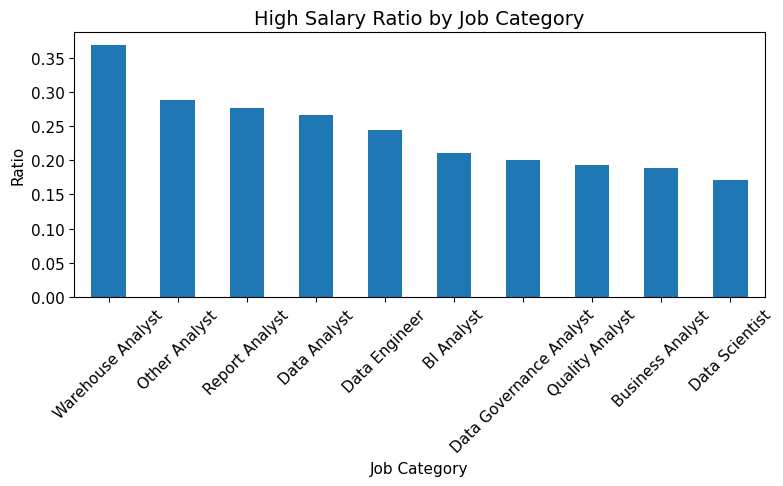

In [105]:
category_total = df["job_category"].value_counts()
category_high_salary = high_salary_df["job_category"].value_counts()

high_salary_ratio_by_category = (category_high_salary / category_total).sort_values(ascending=False)
print(high_salary_ratio_by_category)

plt.figure(figsize=(8, 5))
high_salary_ratio_by_category.plot(kind="bar")
plt.title("High Salary Ratio by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/high_salary_ratio_by_job_category.png", dpi=300, bbox_inches="tight")
plt.show()

### 各岗位类别高薪占比分析
在高薪岗位数量分析的基础上，进一步计算各岗位类别进入高薪区间的比例，以更公平地比较不同岗位类别的高薪机会。

结果显示，Warehouse Analyst、Other Analyst 和 Report Analyst 的高薪占比较高，而 Data Analyst 虽然高薪岗位数量最多，但其高薪占比并不是最高。这说明高薪岗位数量与高薪占比是两个不同维度：前者受岗位总样本量影响较大，后者更能反映某一岗位类别进入高薪区间的相对可能性。

此外，Data Engineer 的高薪占比高于 Business Analyst、BI Analyst 和 Data Scientist，说明在当前样本中，工程类岗位更容易进入高薪区间。需要注意的是，部分岗位类别样本量较小，因此占比结果可能受到样本规模影响，应结合样本数量进行谨慎解读。

### 6.3 各州岗位数量

In [ ]:
df["state"].value_counts().head(20)
#各州岗位数量

state
CA              626
TX              394
NY              345
IL              164
PA              114
AZ               97
NC               89
CO               88
NJ               86
WA               53
VA               48
OH               35
UT               33
FL               27
IN               23
DE               11
Arapahoe, CO      8
GA                4
SC                3
KS                3
Name: count, dtype: int64

结论：数据相关岗位需求主要集中在少数核心州

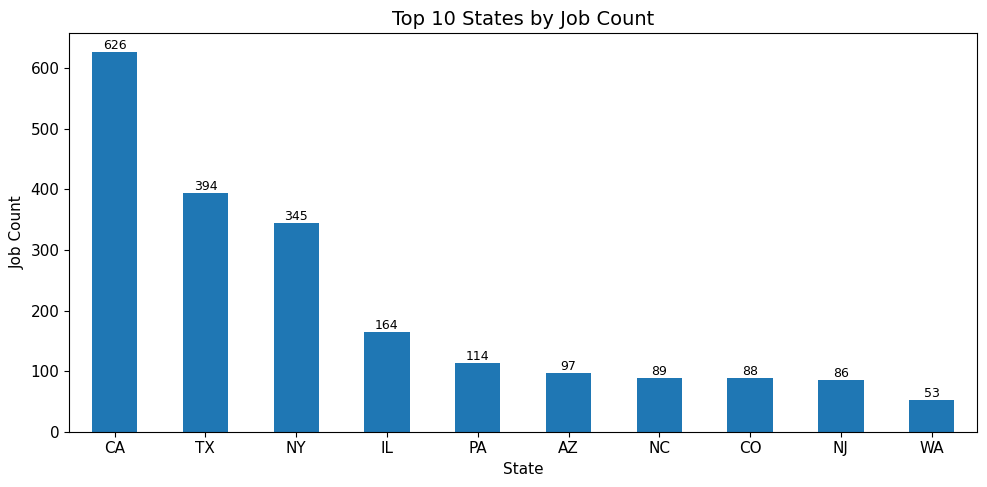

In [ ]:
state_counts = df["state"].value_counts().head(10)

ax = state_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 States by Job Count", fontsize=14)
plt.xlabel("State", fontsize=11)
plt.ylabel("Job Count", fontsize=11)
plt.xticks(rotation=0)

for i, v in enumerate(state_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/top10_states_job_count.png", dpi=300, bbox_inches="tight")
plt.show()
#岗位数量前10的州

In [ ]:
df.groupby("state")["salary_avg"].mean().sort_values(ascending=False).head(20)
#各州平均薪资

state
CA              88.432109
IL              78.310976
CO              73.619318
NJ              73.000000
Arapahoe, CO    72.250000
NY              71.411594
AZ              70.788660
SC              68.333333
NC              68.022472
VA              65.187500
WA              64.754717
PA              61.728070
DE              59.727273
TX              58.751269
FL              51.851852
KS              51.500000
IN              47.500000
OH              45.200000
GA              44.000000
UT              37.530303
Name: salary_avg, dtype: float64

相关系数≈0
公司评分和岗位薪资，在这份数据里几乎没有线性关系

In [ ]:
df[["rating","salary_avg"]].corr()

,rating,salary_avg
rating,1.000000,0.004489
salary_avg,0.004489,1.000000


### 6.4 技能关键词分析

In [99]:

skills = ["python", "sql", "excel", "tableau", "power bi", "spark", "hadoop", "aws"]

skill_count = {}
for skill in skills:
    skill_count[skill] = df["job_description"].str.lower().str.contains(skill, na=False).sum()

skill_series = pd.Series(skill_count).sort_values(ascending=False)
skill_series

sql         1387
excel       1352
python       637
tableau      620
aws          275
power bi     180
hadoop       136
spark         89
dtype: int64

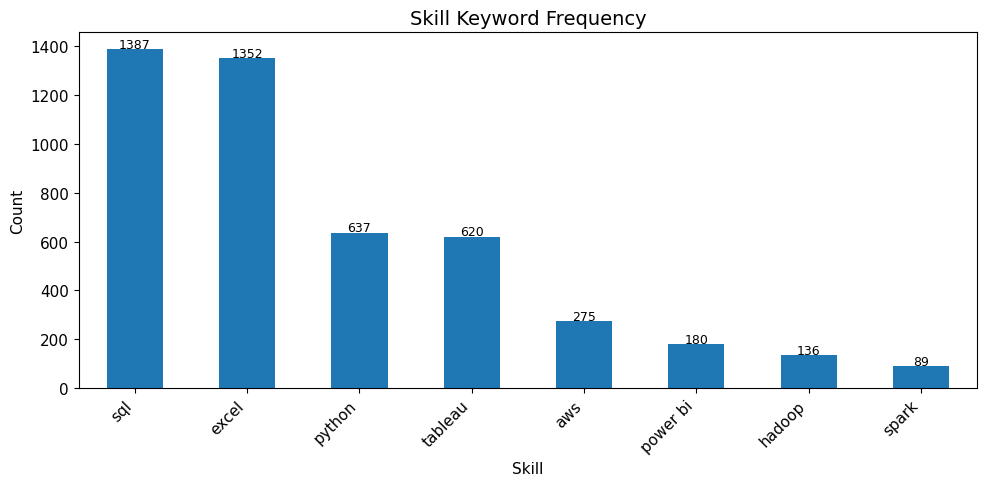

In [100]:
ax = skill_series.plot(kind="bar", figsize=(10, 5))

plt.title("Skill Keyword Frequency", fontsize=14)
plt.xlabel("Skill", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(skill_series.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/skill_keyword_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df.to_csv("../data/clean/jobs_clean.csv", index=False)

## 7.最终项目总结

本项目基于公开招聘岗位数据，使用 Python 对原始数据进行了清洗、特征构造与可视化分析，主要围绕岗位分布、薪资差异、地区分布、技能需求以及高薪岗位画像展开。

主要结论如下：

1. Data Analyst 是样本中数量最多的岗位类别，说明数据分析类岗位在招聘市场中需求最强。

2. 招聘岗位主要集中在 CA、TX、NY 等州，尤其是加州，无论在整体岗位数量还是高薪岗位数量上都表现最突出，说明高薪数据岗位更集中于经济活跃、技术需求较强的地区。

3. 从整体技能词频来看，SQL、Excel、Python 是招聘市场中最常见的核心技能关键词，说明数据查询、表格分析与基础编程能力是数据岗位的通用要求。

4. 从不同岗位类别的技能出现率来看，不同数据岗位在技能要求上存在明显分工：
   - Data Analyst 更偏 SQL、Excel、Python；
   - Data Engineer 更偏 Hadoop、Spark、AWS 等工程化和大数据相关技能；
   - BI Analyst 更强调 SQL、Power BI、Tableau 等数据展示与商业智能能力；
   - Business Analyst 更偏 SQL 与 Excel，工程化技能要求相对较低。

5. 以 `salary_avg` 前 25% 作为高薪岗位标准后发现，高薪岗位数量在 Data Analyst 中最多，但这更多反映了该岗位类别样本量较大；若从高薪占比看，不同岗位类别进入高薪区间的相对机会存在差异，说明“高薪岗位数量”和“高薪岗位占比”是两个不同维度。

6. 高薪岗位在技能要求上更集中于 SQL、Excel、Python、Tableau，说明高薪岗位并不只强调工程类技术，也高度重视数据查询、分析处理和可视化表达等综合能力。

总体来看，本项目表明不同数据类岗位虽然都属于数据方向，但在岗位规模、薪资分布与技能要求上存在明显差异。其中，分析类岗位更偏 SQL 与 Excel，技术类岗位更偏 Python 与大数据相关能力。
